## Installed the required libaries for this project

In [ ]:
!pip install missingno pandas matplotlib seaborn mysql-connector-python numpy

In [ ]:
import missingno as msno
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np
from pathlib import Path

#### Reading CSV file and storing into respective variables

In [ ]:
common_path = Path(r"D:\python-guvi\MDTE13\MiniProject1\Dataset")
df_customers=pd.read_csv(common_path / "Customers.csv", encoding='latin-1')
df_data_dict=pd.read_csv(common_path / "Data_Dictionary.csv")
df_exchange=pd.read_csv(common_path / "Exchange_Rates.csv")
df_products=pd.read_csv(common_path / "Products.csv")
df_sales=pd.read_csv(common_path / "Sales.csv")
df_stores=pd.read_csv(common_path / "Stores.csv")

In [ ]:
df_customers.head()
df_data_dict.head()
df_exchange.head()
df_products.head()
df_sales.head()
df_stores.head()

In [10]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 15266 entries, 0 to 15265
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   CustomerKey  15266 non-null  int64
 1   Gender       15266 non-null  str  
 2   Name         15266 non-null  str  
 3   City         15266 non-null  str  
 4   State Code   15256 non-null  str  
 5   State        15266 non-null  str  
 6   Zip Code     15266 non-null  str  
 7   Country      15266 non-null  str  
 8   Continent    15266 non-null  str  
 9   Birthday     15266 non-null  str  
dtypes: int64(1), str(9)
memory usage: 1.2 MB


In [ ]:
# Check missing values for customers dataset
print(df_customers.isnull().sum())

CustomerKey     0
Gender          0
Name            0
City            0
State Code     10
State           0
Zip Code        0
Country         0
Continent       0
Birthday        0
dtype: int64


In [12]:
#Droping useless columns
df_customers.drop(["State Code","Zip Code"],axis=1,inplace=True)

In [13]:
# Remove duplicate rows
df_customers.drop_duplicates(inplace=True)

In [14]:
# Convert Birthday column to datetime
df_customers['Birthday'] = pd.to_datetime(df_customers['Birthday'], format = '%m/%d/%Y')
df_customers.head()

,CustomerKey,Gender,Name,City,State,Country,Continent,Birthday
0,301,Female,Lilly Harding,WANDEARAH EAST,South Australia,Australia,Australia,1939-07-03
1,325,Female,Madison Hull,MOUNT BUDD,Western Australia,Australia,Australia,1979-09-27
2,554,Female,Claire Ferres,WINJALLOK,Victoria,Australia,Australia,1947-05-26
3,786,Male,Jai Poltpalingada,MIDDLE RIVER,South Australia,Australia,Australia,1957-09-17
4,1042,Male,Aidan Pankhurst,TAWONGA SOUTH,Victoria,Australia,Australia,1965-11-19


In [15]:
#checking null set and data types
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 15266 entries, 0 to 15265
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CustomerKey  15266 non-null  int64         
 1   Gender       15266 non-null  str           
 2   Name         15266 non-null  str           
 3   City         15266 non-null  str           
 4   State        15266 non-null  str           
 5   Country      15266 non-null  str           
 6   Continent    15266 non-null  str           
 7   Birthday     15266 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(6)
memory usage: 954.3 KB


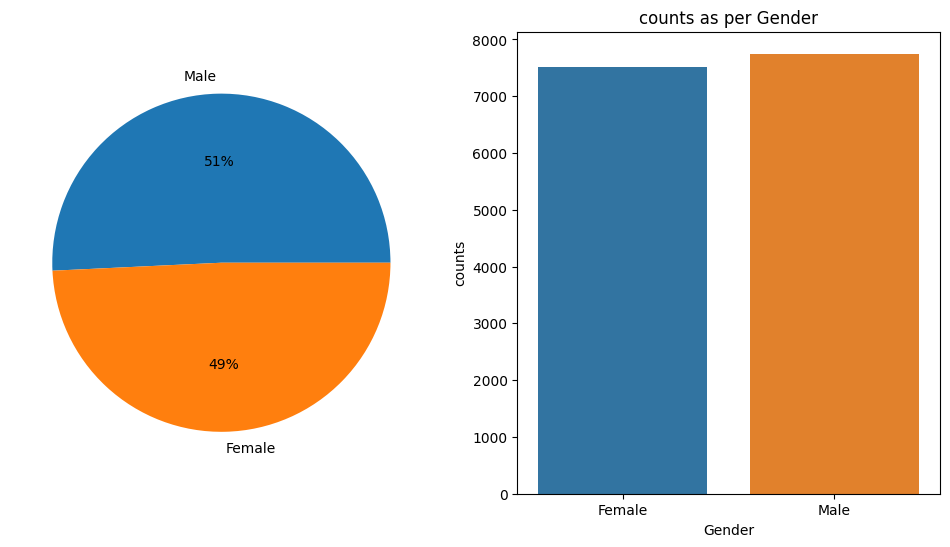

In [16]:
# visualize gender details
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.pie(df_customers["Gender"].value_counts(), autopct='%1.0f%%', labels=['Male', 'Female'])
plt.subplot(1,2,2)
sns.countplot(x= df_customers["Gender"],data=df_customers,hue="Gender")
plt.xlabel("Gender")
plt.ylabel("counts")
plt.title("counts as per Gender")
plt.show()

Text(0.5, 1.0, 'Counts as per Country')

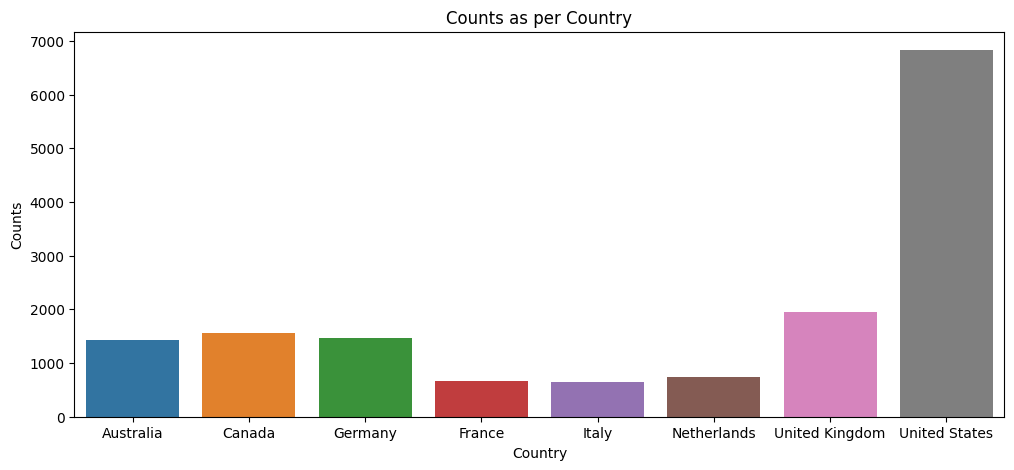

In [17]:
# visualize country counts
plt.figure(figsize=(12,5))
sns.countplot(x= df_customers["Country"],data=df_customers,hue="Country")
plt.xlabel("Country")
plt.ylabel("Counts")
plt.title("Counts as per Country")

In [18]:
# Check missing values for exchange dataset
print(df_exchange.isnull().sum())

Date        0
Currency    0
Exchange    0
dtype: int64


In [19]:
# Summary statistics
print(df_exchange.describe())

# Check data types
print(df_exchange.dtypes)

           Exchange
count  11215.000000
mean       1.061682
std        0.245519
min        0.628500
25%        0.857800
50%        1.000000
75%        1.311900
max        1.725300
Date            str
Currency        str
Exchange    float64
dtype: object


In [20]:
# Convert 'Date' column to datetime objects
df_exchange['Date'] = pd.to_datetime(df_exchange['Date'])

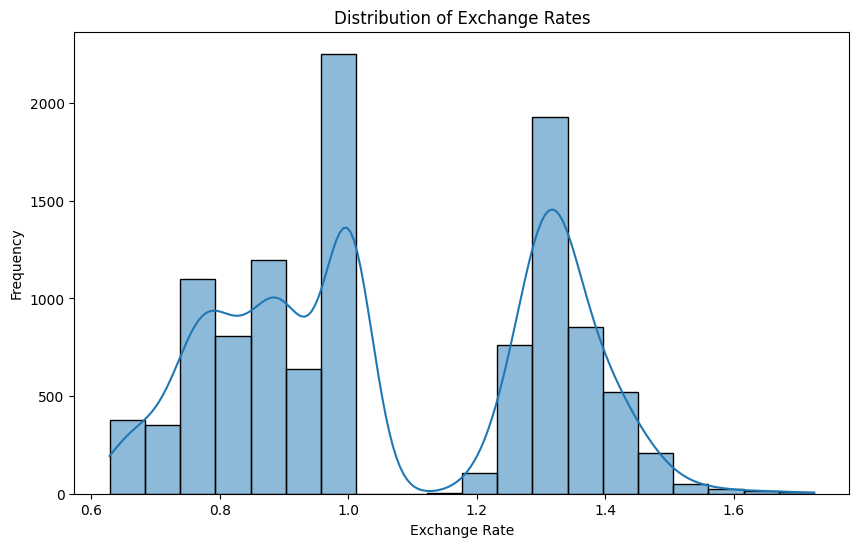

In [21]:
# Visualize the distribution of 'Exchange' rates
plt.figure(figsize=(10, 6))
sns.histplot(df_exchange['Exchange'], bins=20, kde=True)
plt.title('Distribution of Exchange Rates')
plt.xlabel('Exchange Rate')
plt.ylabel('Frequency')
plt.show()

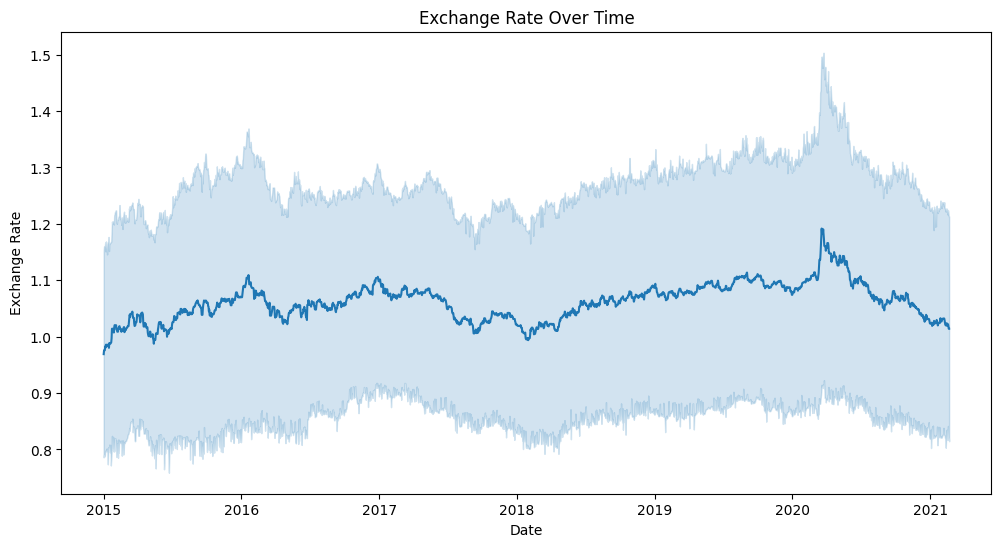

In [22]:
# Analyze the 'Exchange' rate over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Exchange', data=df_exchange)
plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

In [23]:
# Check missing values for products dataset
print(df_products.isnull().sum())

ProductKey        0
Product Name      0
Brand             0
Color             0
Unit Cost USD     0
Unit Price USD    0
SubcategoryKey    0
Subcategory       0
CategoryKey       0
Category          0
dtype: int64


In [24]:
# Inspect the data
print(df_products.info())  # Get information about the dataframe
print(df_products.describe())  # Summary statistics for numerical columns

<class 'pandas.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ProductKey      2517 non-null   int64
 1   Product Name    2517 non-null   str  
 2   Brand           2517 non-null   str  
 3   Color           2517 non-null   str  
 4   Unit Cost USD   2517 non-null   str  
 5   Unit Price USD  2517 non-null   str  
 6   SubcategoryKey  2517 non-null   int64
 7   Subcategory     2517 non-null   str  
 8   CategoryKey     2517 non-null   int64
 9   Category        2517 non-null   str  
dtypes: int64(3), str(7)
memory usage: 196.8 KB
None
        ProductKey  SubcategoryKey  CategoryKey
count  2517.000000     2517.000000  2517.000000
mean   1259.000000      491.810091     4.878824
std     726.739637      229.887134     2.299170
min       1.000000      101.000000     1.000000
25%     630.000000      305.000000     3.000000
50%    1259.000000      406.000000     4.000000

In [25]:
# Data Type Conversion
# Convert columns to the appropriate data types if needed
# Example: Convert 'Unit Cost USD' and 'Unit Price USD' to numeric type
df_products['Unit Cost USD'] = df_products['Unit Cost USD'].str.replace('$', '').str.replace(",", "").str.strip().astype(float)
df_products['Unit Price USD'] = df_products['Unit Price USD'].str.replace('$', '').str.replace(",", "").str.strip().astype(float)

In [26]:
# Remove Duplicates
# Check for duplicate rows and remove them if necessary
df_products.drop_duplicates(inplace=True)

In [27]:
df_products.drop(["SubcategoryKey"],axis=1,inplace=True)


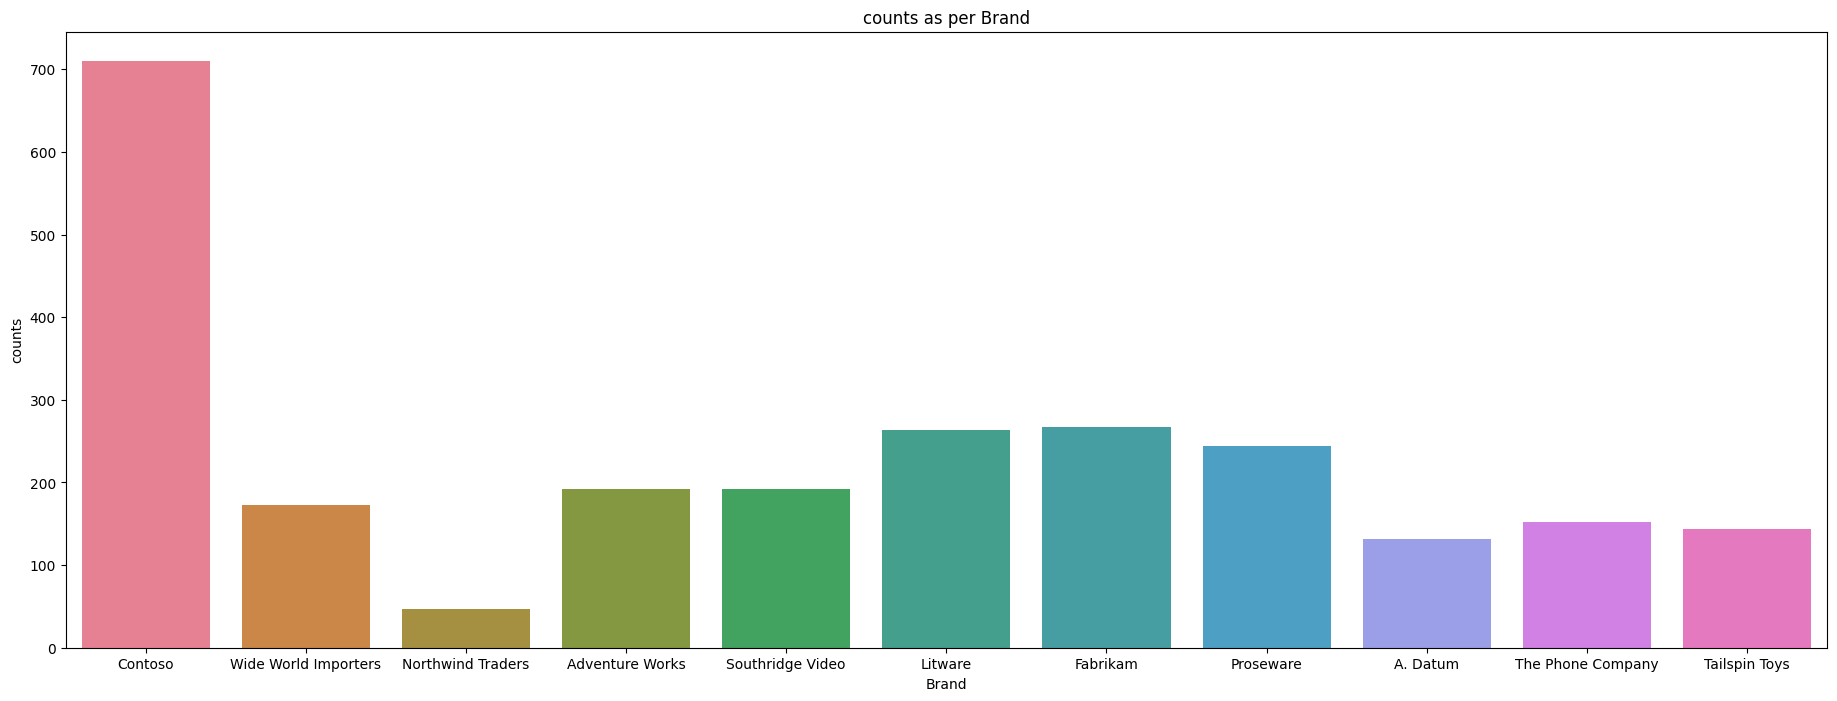

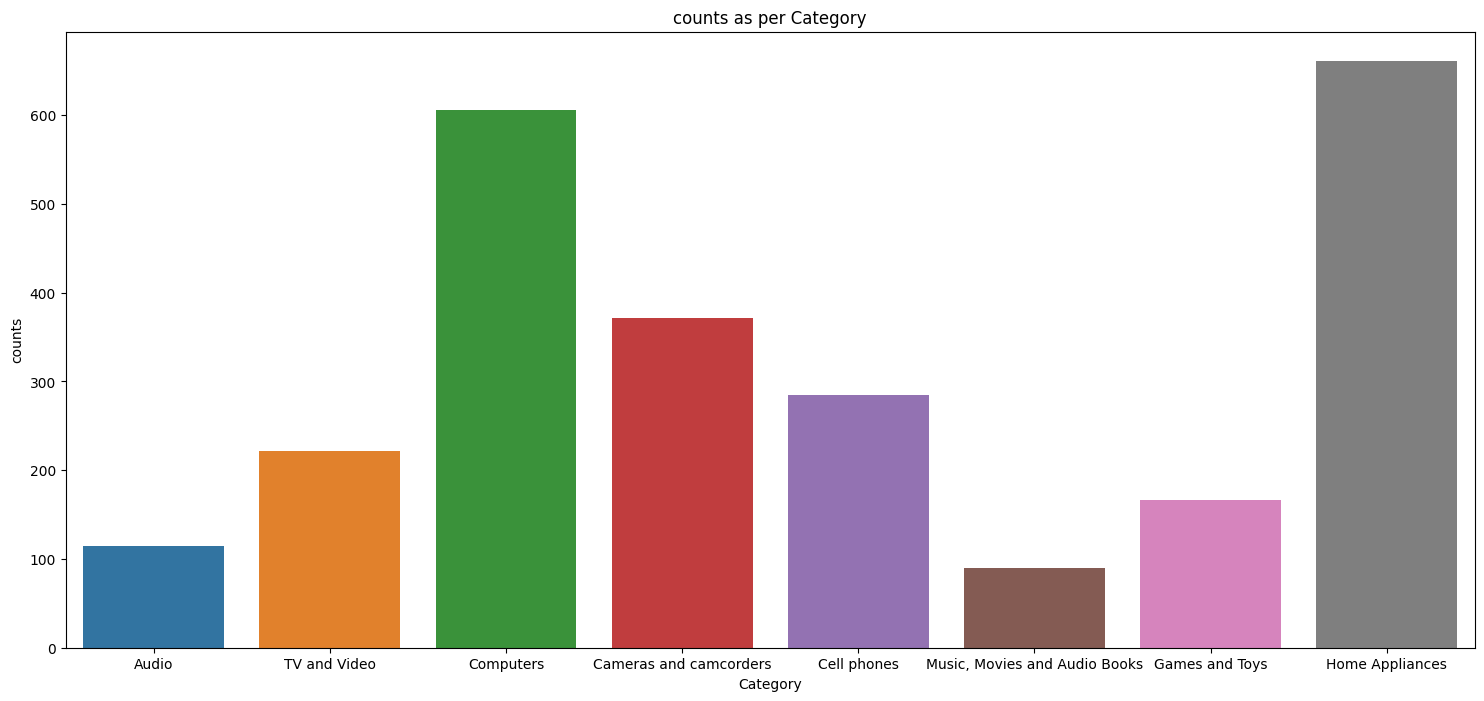

In [28]:
#visualize the brand and category
plt.figure(figsize=(50,8))
plt.subplot(1,2,1)
sns.countplot(x=df_products["Brand"],data=df_products,hue="Brand")
plt.xlabel("Brand")
plt.ylabel("counts")
plt.title("counts as per Brand")
plt.show()
plt.figure(figsize=(40,8))
plt.subplot(1,2,2)
sns.countplot(x=df_products["Category"],data=df_products,hue="Category")
plt.xlabel("Category")
plt.ylabel("counts")
plt.title("counts as per Category")
plt.show()

In [29]:
# Get information about the dataframe, including data types and missing values
print(df_sales.info())

<class 'pandas.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Order Number   62884 non-null  int64
 1   Line Item      62884 non-null  int64
 2   Order Date     62884 non-null  str  
 3   Delivery Date  13165 non-null  str  
 4   CustomerKey    62884 non-null  int64
 5   StoreKey       62884 non-null  int64
 6   ProductKey     62884 non-null  int64
 7   Quantity       62884 non-null  int64
 8   Currency Code  62884 non-null  str  
dtypes: int64(6), str(3)
memory usage: 4.3 MB
None


In [30]:
# Generate descriptive statistics for numerical columns
print(df_sales.describe())

       Order Number     Line Item   CustomerKey      StoreKey    ProductKey  \
count  6.288400e+04  62884.000000  6.288400e+04  62884.000000  62884.000000   
mean   1.430905e+06      2.164207  1.180797e+06     31.802144   1125.859344   
std    4.532963e+05      1.365170  5.859634e+05     22.978188    709.244010   
min    3.660000e+05      1.000000  3.010000e+02      0.000000      1.000000   
25%    1.121017e+06      1.000000  6.808580e+05      8.000000    437.000000   
50%    1.498016e+06      2.000000  1.261200e+06     37.000000   1358.000000   
75%    1.788010e+06      3.000000  1.686496e+06     53.000000   1650.000000   
max    2.243032e+06      7.000000  2.099937e+06     66.000000   2517.000000   

           Quantity  
count  62884.000000  
mean       3.144790  
std        2.256371  
min        1.000000  
25%        1.000000  
50%        2.000000  
75%        4.000000  
max       10.000000  


In [31]:
# Check for missing values in each column
print(df_sales.isnull().sum())

Order Number         0
Line Item            0
Order Date           0
Delivery Date    49719
CustomerKey          0
StoreKey             0
ProductKey           0
Quantity             0
Currency Code        0
dtype: int64


In [32]:
# Convert 'Order Date' column to datetime objects
df_sales['Order Date'] = pd.to_datetime(df_sales['Order Date'])
df_sales['Delivery Date'] = pd.to_datetime(df_sales['Delivery Date'], format="%m/%d/%Y", errors='coerce').dt.date

In [33]:
# fill the missing values
df_sales["Delivery Date"]=df_sales["Delivery Date"].fillna(0)

In [34]:
# Check for duplicates
print(df_sales.duplicated().sum())

0


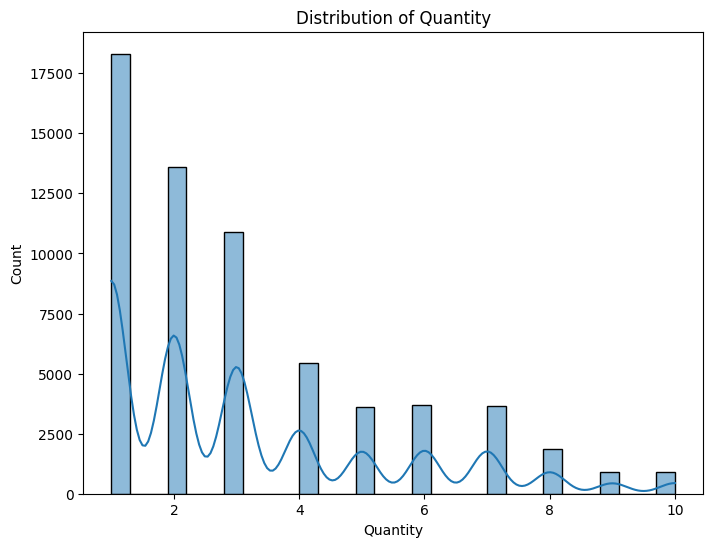

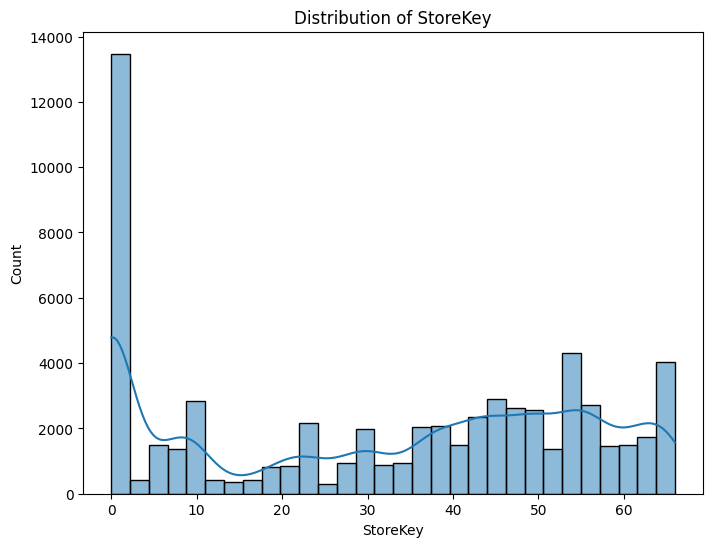

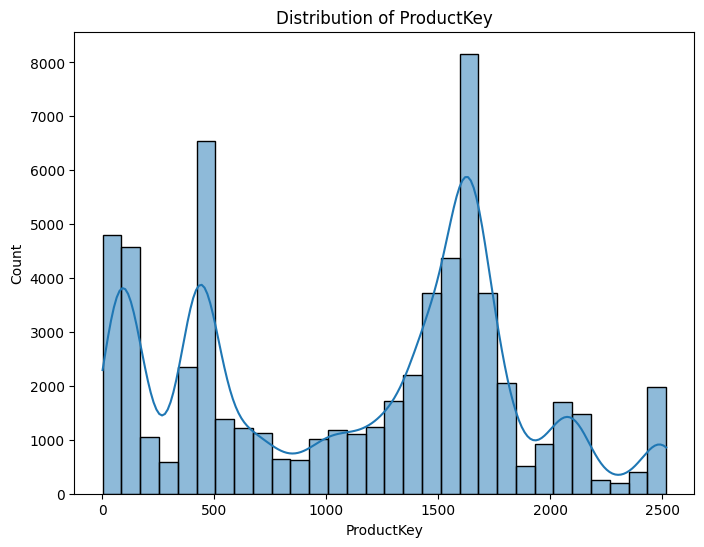

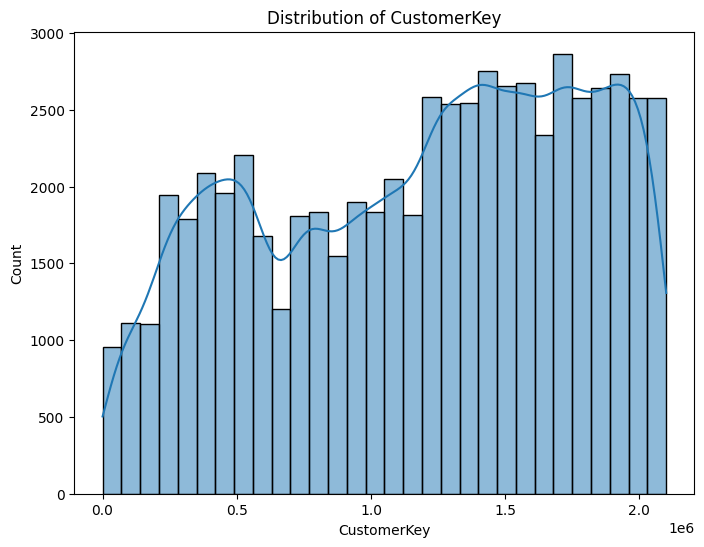

In [35]:
# Explore distributions of numerical features
numerical_features = ['Quantity', 'StoreKey', 'ProductKey', 'CustomerKey']
for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.histplot(df_sales[feature], bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

In [36]:
# Check missing values for stores dataset
print(df_stores.isnull().sum())

StoreKey         0
Country          0
State            0
Square Meters    1
Open Date        0
dtype: int64


In [37]:
# Display basic information about the dataframe
print(df_stores.info())

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   StoreKey       67 non-null     int64  
 1   Country        67 non-null     str    
 2   State          67 non-null     str    
 3   Square Meters  66 non-null     float64
 4   Open Date      67 non-null     str    
dtypes: float64(1), int64(1), str(3)
memory usage: 2.7 KB
None


In [38]:
# Convert 'Open Date' to datetime objects
df_stores['Open Date'] = pd.to_datetime(df_stores['Open Date'])

In [39]:
df_stores.fillna(0)

,StoreKey,Country,State,Square Meters,Open Date
0,1,Australia,Australian Capital Territory,595.0,2008-01-01
1,2,Australia,Northern Territory,665.0,2008-01-12
2,3,Australia,South Australia,2000.0,2012-01-07
3,4,Australia,Tasmania,2000.0,2010-01-01
4,5,Australia,Victoria,2000.0,2015-12-09
...,...,...,...,...,...
62,63,United States,Utah,2000.0,2008-03-06
63,64,United States,Washington DC,1330.0,2010-01-01
64,65,United States,West Virginia,1785.0,2012-01-01
65,66,United States,Wyoming,840.0,2014-01-01


In [40]:
# Remove duplicate rows (if any)
df_stores.drop_duplicates(inplace=True)

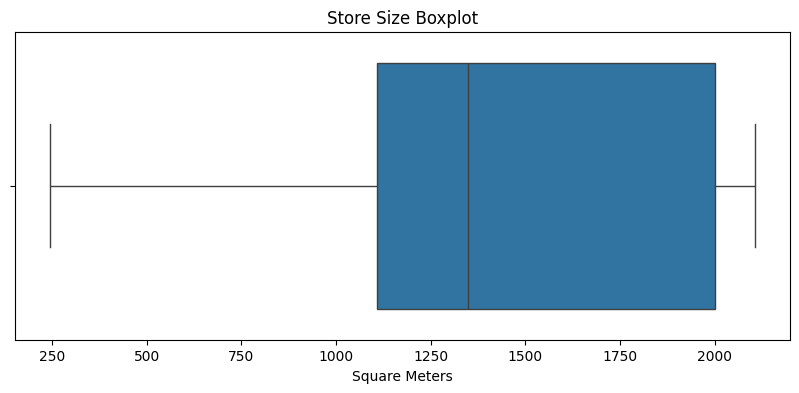

In [41]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df_stores['Square Meters'])
plt.title("Store Size Boxplot")
plt.show()

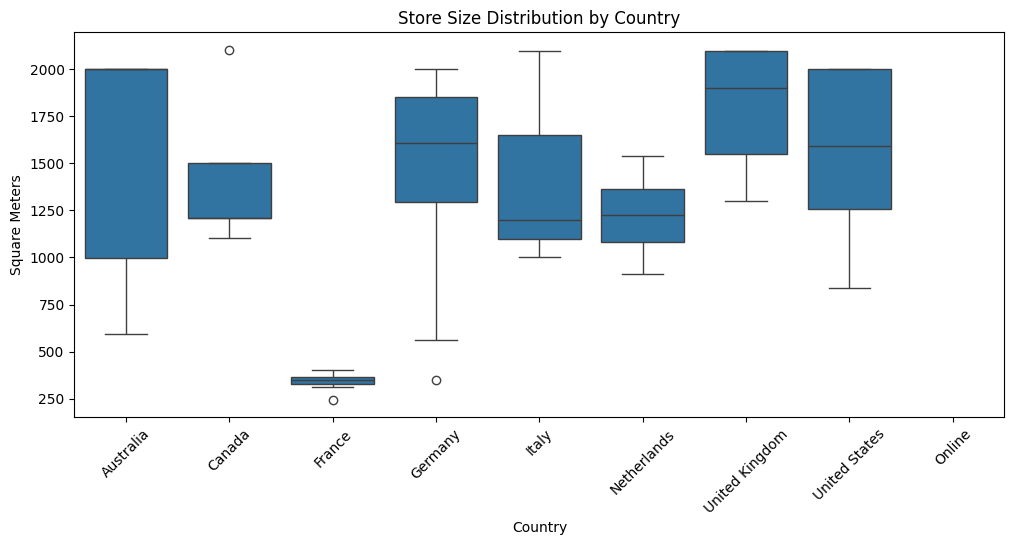

In [42]:
plt.figure(figsize=(12,5))
sns.boxplot(
    x='Country',
    y='Square Meters',
    data=df_stores
)

plt.title("Store Size Distribution by Country")
plt.xticks(rotation=45)

plt.show()

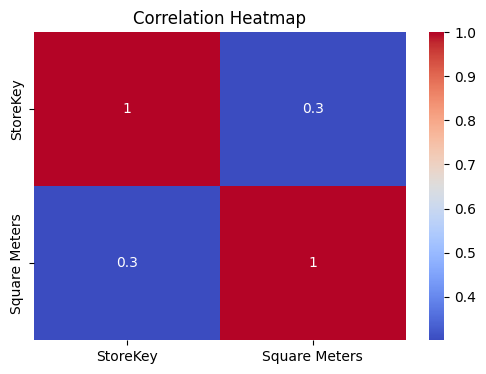

In [43]:
numeric_df = df_stores.select_dtypes(include=['number'])

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

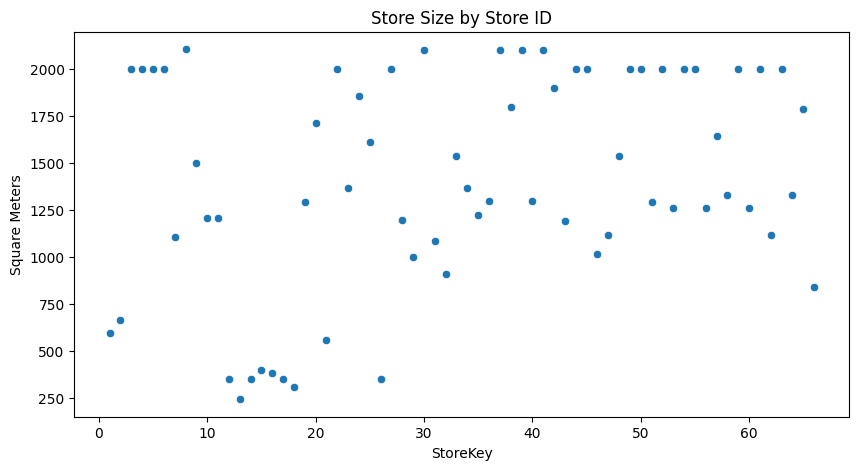

In [44]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='StoreKey',
    y='Square Meters',
    data=df_stores
)

plt.title("Store Size by Store ID")

plt.show()